# Estudio comparativo de algoritmos en el problema Taxi-v3

*Description*: Implementación y análisis del algoritmo SARSA Semi-gradiente utilizando aproximación de funciones mediante Redes Neuronales Artificiales para resolver el problema LunarLander-v3.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/22

## Preparación del entorno


In [ ]:
#@title Copiar el repositorio.

#git clone https://github.com/ldaniel-hm/eml_k_bandit.git
#!cd eml_k_bandit/
#@title Importamos todas las clases y funciones

#import sys

# Añadir los directorio fuentes al path de Python
#sys.path.append('/content/eml_k_bandit')


# Verificar que se han añadido correctamente
#print(sys.path)

In [1]:
# @title Instalación e importación de librerías
# !pip install "gymnasium[box2d]" torch numpy matplotlib tqdm

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

from utils import plot_training_metrics
from agents import SemiGradientSarsaAgent, QNetwork

import imageio
import base64
from IPython.display import HTML
# Garantizamos reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Experimento

El experimento evalúa el rendimiento de un agente que utiliza el algoritmo on-policy SARSA Semi-gradiente para aprender a aterrizar el módulo lunar. Este entorno consta de:
- Espacio de estados: Vector continuo de 8 dimensiones (coordenadas x/y, velocidades x/y, ángulo, velocidad angular, y contacto de las dos patas).
- Espacio de acciones: 4 acciones discretas (0: nada, 1: motor izquierdo, 2: motor principal, 3: motor derecho).
- Recompensa: Recompensas basadas en la distancia a la plataforma, velocidad, inclinación, uso de combustible y un premio/castigo final de +100/-100 por aterrizar o estrellarse. El entorno se considera ``resuelto'' si se alcanzan 200 puntos.

**Objetivo del experimento:**

- Implementar la parametrización de la función de valor de acción $\hat{q}(s, a, \mathbf{w})$ mediante una red neuronal.
- Implementar el bucle de control de SARSA utilizando backpropagation para aproximar el gradiente $\nabla \hat{q}(S, A, \mathbf{w})$.
- Analizar la curva de aprendizaje y la estabilidad del entrenamiento.

## Arquitectura de la Red Neuronal y Política

A diferencia de los métodos tabulares, aquí los pesos $\mathbf{w}$ son los parámetros de la red neuronal.

In [2]:
# @title Bucle de Entrenamiento SARSA Semi-gradiente

def train_sarsa_lunar_lander(agent, episodes=1000):
    
    rewards_history = []
    env = agent.env
    for t in tqdm(range(episodes)):
        state, info = env.reset(seed=SEED if t==0 else None)  # Reproducibilidad en el estado inicial
        # action = agent.get_action(state)  # A
        
        total_reward = 0
        done = False
        
        while not done:
            # Tomar acción A, observar R, S'
            action, _ = agent.get_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # # Elegir A' desde S' usando la política actual
            # next_action = agent.get_action(next_state)
            
            # Actualizar pesos: w <- w + alpha * [R + gamma*q(S',A') - q(S,A)] * grad(q)
            # agent.update(state, action, reward, next_state, next_action, done)
            agent.update(
                obs=state,
                action=action,
                reward=reward,
                terminated=terminated,
                next_obs=next_state,
            )

            state = next_state
            #action = next_action
            total_reward += reward
            
        agent.decay_epsilon()
        rewards_history.append(total_reward)
        
    env.close()
    return rewards_history, agent


c:\Users\aaron\miniconda3\envs\dlpln\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
100%|██████████| 1500/1500 [25:06<00:00,  1.00s/it]


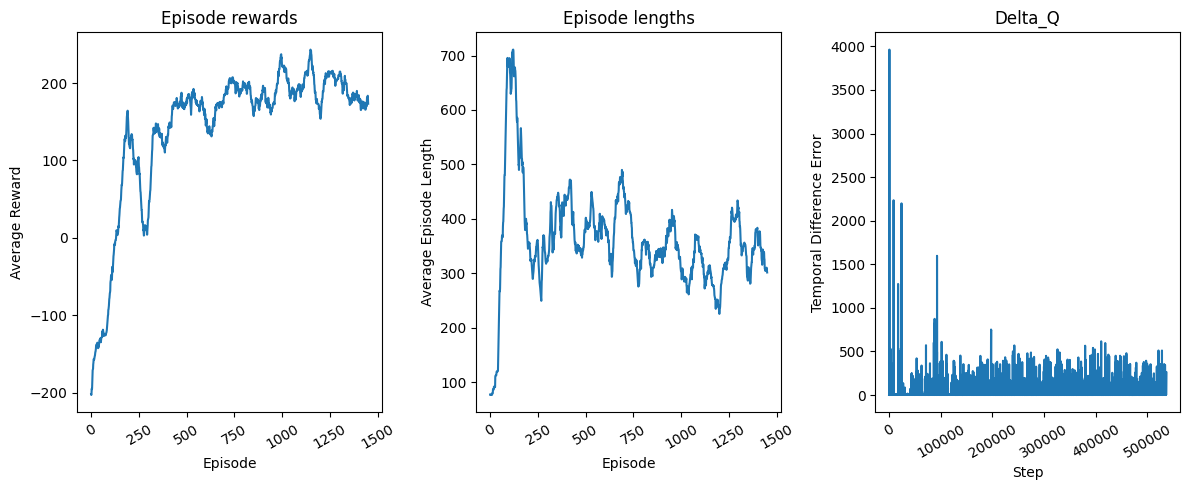

Test Results over 1000 episodes:
Win Rate: 94.4%
Average Reward: 214.600
Standard Deviation: 85.958


(np.float64(0.944),
 np.float64(214.60019483234623),
 np.float64(85.95779531405952))

In [3]:
learning_rate = 0.001
start_epsilon = 1.0
epsilon_decay = 0.995
final_epsilon = 0.05
discount_factor = 0.99
n_episodes = 1500

env = gym.make("LunarLander-v3")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent = SemiGradientSarsaAgent(
    env=env,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
rewards, trained_agent = train_sarsa_lunar_lander(agent, episodes=n_episodes)

plot_training_metrics(env.return_queue, env.length_queue, trained_agent.training_error, rolling_length=50)
trained_agent.test(num_episodes=1000)

## Análisis de Resultados y Conclusiones

- Recompensa promedio por episodio: Al inicio, el agente obtendrá puntuaciones cercanas a -200 o -300, ya que los motores se activan aleatoriamente y el módulo se estrella rápidamente o sale de la pantalla. 
- A medida que $\epsilon$ decae y los pesos $\mathbf{w}$ se ajustan, la recompensa media aumenta.
- La inestabilidad (gráficas de recompensa que suben a 100 y de repente caen en picado) es una característica de usar Redes Neuronales con métodos on-line como SARSA.
- Las muestras sucesivas $(S, A, R, S')$ están altamente correlacionadas, lo que hace que la red neuronal "olvide" lo aprendido en zonas anteriores del espacio de estados.
- Mientras que en problemas tabulares SARSA y Q-Learning convergen con garantías teóricas, al introducir Redes Neuronales el control del hiperparámetro de tasa de aprendizaje ($\alpha$) y la arquitectura de la red determinan la convergencia. 
- Una mejora es usar DQN (Deep Q-Networks), que añade un "Buffer de Repetición" para romper la correlación y una "Red Objetivo" (Target Network) para estabilizar el gradiente.

In [4]:
# Guardar pesos del modelo entrenado
torch.save(trained_agent.q_network.state_dict(), "sarsa_lunarlander_qnetwork.pth")
print("Pesos guardados correctamente.")

Pesos guardados correctamente.


In [2]:
def greedy_action(q_network, state):
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        q_values = q_network(state_tensor)
        action = torch.argmax(q_values).item()
    return action

def run_episode_greedy_lunarlander(env, q_network, max_steps=1000):
    frames = []
    state, _ = env.reset()
    
    for _ in range(max_steps):
        frame = env.render()
        frames.append(frame)

        action = greedy_action(q_network, state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        
        if terminated or truncated:
            frames.append(env.render())
            break

    return frames

def frames_to_gif(frames, filename="lunarlander_sarsa.gif"):
    with imageio.get_writer(filename, mode='I') as writer:
        for frame in frames:
            writer.append_data(frame)
    return filename

def display_gif(gif_path):
    with open(gif_path, 'rb') as f:
        video = f.read()
    b64 = base64.b64encode(video)
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" />')

c:\Users\aaron\miniconda3\envs\dlpln\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


GIF guardado en: lunarlander_sarsa.gif



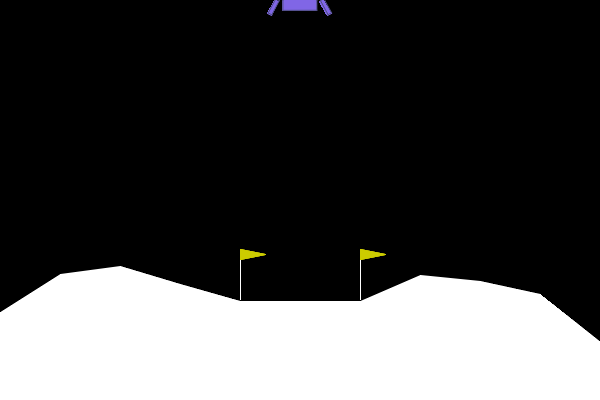

In [3]:
# Crear entorno con modo render para capturar imágenes
env_demo = gym.make("LunarLander-v3", render_mode='rgb_array')

state_dim = env_demo.observation_space.shape[0]
action_dim = env_demo.action_space.n

# Instanciar red con misma arquitectura
q_net_loaded = QNetwork(state_dim, action_dim, hidden_dim=128)

# Cargar pesos
q_net_loaded.load_state_dict(torch.load("sarsa_lunarlander_qnetwork.pth"))
q_net_loaded.eval()

# Ejecutar episodio greedy
frames = run_episode_greedy_lunarlander(env_demo, q_net_loaded)

env_demo.close()

# Crear GIF
gif_path = frames_to_gif(frames, filename="lunarlander_sarsa.gif")
print("GIF guardado en:", gif_path)

# Mostrar GIF
display_gif(gif_path)